> # **FP Tegraf**

Proyek untuk mengelompokkan akun dengan narasi yang mirip untuk mengetahui akun paling berpengaruh dan mengidentifikasi indikasi koordinasi dengan dataset pemilu 2024 oleh Drone Emprit. Dalam proses mencapai tujuannya, terdapat beberapa masalah:

* Pengelompokan akun dengan penggunaan kalimat yang berbeda namun bermakna sama
* Bagaimana cara mendeteksi suatu "_Koordinasi_" apa indikatornya
* Dataset Kotor(Penuh dengan RT[Re-tweet], link(ex:https), dan emoji yang menjadi kumpulan string aneh)
* Gimana cara menggambarkan 1000 node yang berhubungan

Untuk itu maka solusi awalnya adalah:
* Menggunakan embeding kemiripan makna(sentence-transformers) bukan literal(TF-IDF) dan menggunakan _matrix cosine similarity_(`util.cos_sim`)
* Menggunakan konstrain waktu. Tweet yang memiliki narasi dan waktu yang sama
* Menggunakan Gelphi dan menyeting nilai tresholdnya agar graf terbentuk dengan benar

Mengapa tidak memakai FAISS untuk mencari semantic similarity?

Karena FAISS menggunakan aproksimasi demi mencapai kecepatan. FAISS sendiri dirancang dengan asumsi data yang besar. Pada kasus ini, datanya hanya $1000$, maka lebih baik menggunakan _cosine similarity_ demi tingkat keakuratan yang lebih tinggi

## Kesimpulan setelah percobaan

Graf yang dihasilkan terlihat baik, namun belum bisa diambil kesimpulan apakah itu sudah benar atau tidak. Graf juga tidak memberikan kejelasan mengenai apa kesamaan suatu kluster dan yang mana yang merupakan indikasi koordinasi ataupun tokoh utamanya.

### Saran Selanjutnya
* Gunakan sampel yang lebih kecil lagi untuk membuktikan kebenaran proyek ini
* Beri tambahan fitur agar bisa dilihat pada graf kesamaan apa yang ada di tiap kluster

In [ ]:
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 117.8 MB/s eta 0:00:00


In [ ]:
#Imports
import glob
import os
import re
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, util
from google.colab import drive
import networkx as nx
from pyvis.network import Network
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#Mounting
drive.mount('/content/drive')
main_folder_path = "/home/data/kuliah/rka/tegrf/finalproject/data/DE-sample-X-capres2024/DE-sample-X-capres2024"
ans_path = main_folder_path + "/data-twit-anies.json"
owo_path = main_folder_path + "/data-twit-prabowo.json"
njar_path = main_folder_path + "/data-twit-ganjar.json"
test_folder = "/home/data/kuliah/rka/tegrf/finalproject/data/DE-sample-X-capres2024/DE-sample-X-capres2024"

Mounted at /content/drive


In [ ]:
# =====================================================================
# MODUL 1: DATA INGESTION & CLEANING
# =====================================================================
def load_and_combine_json(main_folder, file_pattern="data-twit-*.json", max_rows=1000):
    """Membaca seluruh file JSON paslon dari folder tertentu dan menggabungkannya."""
    print("Membaca data tweet mentah...")

    # Gabungkan path folder utama dengan pola file (Menjadi: /content/drive/MyDrive/.../data-twit-*.json)
    search_path = os.path.join(main_folder, file_pattern)
    file_paths = glob.glob(search_path)

    if not file_paths:
        raise FileNotFoundError(
            f"Tidak ditemukan file dengan pola '{search_path}'. Pastikan path Google Drive sudah benar."
        )

    all_dfs = []
    for path in file_paths:
        print(f"-> Memuat {path}")
        # Ambil kolom esensial
        temp_df = pd.read_json(path)[["name", "content", "date_created"]]
        all_dfs.append(temp_df)

    df = pd.concat(all_dfs, ignore_index=True)
    df = df.head(max_rows)  # Batasi sampel untuk optimalisasi waktu
    print(f"Total data sukses dimuat: {len(df)} baris.\n")
    return df

In [ ]:
def preprocess_tweets(df):
    """Membersihkan teks tweet dari noise karakter mentah Twitter/X."""
    print("Melakukan preprocessing teks...")

    def clean_minimal(text):
        if not isinstance(text, str):
            return ""
        # Hapus penanda Retweet (RT) di awal kalimat
        text = re.sub(r"^rt\s+", "", text, flags=re.IGNORECASE)
        # Hapus URL/Link web
        text = re.sub(r"https?://\S+|www\.\S+", "", text)
        return text.strip()

    df["cleaned_content"] = df["content"].apply(clean_minimal)
    # Pastikan tipe data datetime untuk perhitungan temporal
    df["date_created"] = pd.to_datetime(df["date_created"])
    return df


In [ ]:
# =====================================================================
# MODUL 2: AI SEMANTIC EMBEDDING
# =====================================================================
def generate_embeddings(sentences, model_name):
    """Mengubah teks menjadi vektor embedding menggunakan pre-trained model AI."""
    print(f"Memuat Model AI: {model_name}")
    model = SentenceTransformer(model_name)

    print("Mengonversi teks ke vektor semantik (Embedding)...")
    embeddings = model.encode(
        sentences, convert_to_tensor=True, show_progress_bar=True
    )
    return embeddings


In [ ]:
# =====================================================================
# MODUL 3: JARINGAN KOORDINASI & FILTER (CORE LOGIC)
# =====================================================================
def extract_coordination_edges(df, embeddings, config):
    """Mengekstrak hubungan koordinasi (Edges) berdasarkan kesamaan makna teks

    dan kedekatan waktu postingan.
    """
    print("\nMengekstrak jaringan koordinasi...")
    n = len(df)
    edges_list = []

    # Hitung matriks kemiripan kosinus antar seluruh vektor teks secara serentak
    cosine_scores = util.cos_sim(embeddings, embeddings)

    # Ekstraksi berpasangan (Mencegah duplikasi i-j dan j-i)
    for i in range(n):
        for j in range(i + 1, n):
            # Aturan 1: Lewati jika tweet berasal dari akun yang sama
            if df.iloc[i]["name"] == df.iloc[j]["name"]:
                continue

            # Aturan 2: Cek Ambang Batas Semantik Teks
            s_text = cosine_scores[i][j].item()
            if s_text < config["THRESHOLD_TEXT"]:
                continue

            # Aturan 3: Cek Jendela Jarak Waktu (Temporal)
            t_i = df.iloc[i]["date_created"]
            t_j = df.iloc[j]["date_created"]
            delta_t = abs((t_i - t_j).total_seconds())

            if delta_t > config["THRESHOLD_TIME"]:
                continue

            # Perhitungan Rumus Matematis
            s_time = np.exp(-config["LAMBDA"] * delta_t)
            w_ij = (config["ALPHA"] * s_text) + ((1 - config["ALPHA"]) * s_time)

            edges_list.append(
                {
                    "Source": df.iloc[i]["name"],
                    "Target": df.iloc[j]["name"],
                    "Weight": w_ij,
                    "s_text": s_text,
                    "s_time": s_time,
                    "w_ij": w_ij,
                }
            )

    return edges_list

In [ ]:
# =====================================================================
# MODUL 4: AGREGASI JARINGAN & OUTPUT CSV
# =====================================================================
def export_network_to_csv(edges_list, output_filename="political_edges.csv"):
    """Mengelompokkan edge ganda (agregasi) dan mengekspor hasilnya ke file CSV."""
    if not edges_list:
        print(
            "\n[Hasil] Tidak ditemukan pola koordinasi dengan konfigurasi threshold saat ini."
        )
        return None

    edges_df = pd.DataFrame(edges_list)

    # Agregasi: Jika akun A & B berkoordinasi di beberapa tweet berbeda, ambil nilai rata-ratanya
    final_edges = (
        edges_df.groupby(["Source", "Target"])["Weight"].mean().reset_index()
    )

    final_edges.to_csv(output_filename, index=False)
    print(
        f"\n[Sukses] Berhasil mengekstrak {len(final_edges)} edges koordinasi."
    )
    print(f"File disimpan dengan nama: '{output_filename}'")
    print(final_edges.head())
    return final_edges


In [ ]:
from pandas.io import json
# Konfigurasi Parameter Proyek
CONFIG = {
    "MODEL_NAME": "symanto/sn-xlm-roberta-base-snli-mnli-anli-xnli",
    "MAX_ROWS": 1000,
    "ALPHA": 0.5, # Rasio perhatian antara fokus dengan teks atau interval waktu(0.5 berarti 50-50[setara])
    "LAMBDA": 0.01155, # Tingkat penyusutan eksponensial(perbedaan waktu)
    "THRESHOLD_TEXT": 0.6, # Minimal tingkat kemiripan text agar bisa dikatakan sama
    "THRESHOLD_TIME": 3000, # Maksimal interval waktu suatu text yang mirip 600 = 10 menit
}

#main_folder_path = test_folder
try:
    # Langkah 1: Ekstraksi dan Pembersihan Data (Berikan input main_folder_path)
    raw_data = load_and_combine_json(
        main_folder=main_folder_path,#test_folder
        file_pattern="data-twit-*.json",#anorganic.json
        max_rows=CONFIG["MAX_ROWS"]
    )
    cleaned_data = preprocess_tweets(raw_data)
    print(cleaned_data.head())
    print(cleaned_data.info())
    cleaned_data.to_csv(os.path.join(main_folder_path, "cleaned_data.csv"), index=False)
    # Langkah 2: Proses Komputasi AI Semantik
    tweet_embeddings = generate_embeddings(
        sentences=cleaned_data["cleaned_content"].tolist(),
        model_name=CONFIG["MODEL_NAME"],
    )

    # Langkah 3: Ekstraksi Struktur Koordinasi Hubungan
    extracted_edges = extract_coordination_edges(
        df=cleaned_data, embeddings=tweet_embeddings, config=CONFIG
    )
    csv_name = "relation.csv"

    # Langkah 4: Penyimpanan Hasil Akhir Data Graf langsung ke Google Drive
    output_file = os.path.join(main_folder_path, csv_name)
    export_network_to_csv(
        edges_list=extracted_edges,
        output_filename=output_file,
    )

except Exception as e:
    print(f"\n[Eror Sistem] Terjadi kegagalan proses: {str(e)}")

Membaca data tweet mentah...
-> Memuat /content/drive/MyDrive/ITS/Tegraf FP/DE-sample-X-capres2024/DE-sample-X-capres2024/data-twit-ganjar.json
-> Memuat /content/drive/MyDrive/ITS/Tegraf FP/DE-sample-X-capres2024/DE-sample-X-capres2024/data-twit-anies.json
-> Memuat /content/drive/MyDrive/ITS/Tegraf FP/DE-sample-X-capres2024/DE-sample-X-capres2024/data-twit-prabowo.json
Total data sukses dimuat: 1000 baris.

Melakukan preprocessing teks...
              name                                            content  \
0      khansa_lily  @Melihat_Indo @ganjarpranowo Langkah Pak Ganja...   
1          KpellyD  Ganjar Pranowo Idola RakyatÂ \n\n Ganjar Mahfu...   
2  SAGAIslamJateng  Dalam atmosfer yang sarat dengan kebersamaan d...   
3  TPNGanjarMahfud  TPD Ganjar-Mahfud Jabar Optimistis Menang 40 P...   
4  go83996201vinay  Senyumin ajaÂ \n\n Ganjar Mahfud Hebat #L3bihb...   

               date_created                                    cleaned_content  
0 2024-01-04 17:59:59+00:00  @Melih

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.73k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Mengonversi teks ke vektor semantik (Embedding)...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]


Mengekstrak jaringan koordinasi...

[Sukses] Berhasil mengekstrak 3436 edges koordinasi.
File disimpan dengan nama: '/content/drive/MyDrive/ITS/Tegraf FP/DE-sample-X-capres2024/DE-sample-X-capres2024/relation.csv'
            Source           Target    Weight
0  05444t56409317a     0556409317ae  0.961166
1  05444t56409317a     05564v09317a  0.971943
2  05444t56409317a    AlbiPutz75864  0.920141
3  05444t56409317a  AlvaAugust14185  0.898833
4  05444t56409317a   AsdasdasOpopop  0.838158


In [ ]:
# =====================================================================
# MODUL 4: ANALISIS TEORI GRAF (NETWORKX)
# =====================================================================
def analyze_coordination_graph(csv_path,df):
    print("Memuat file jaringan koordinasi...")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"File tidak ditemukan di: {csv_path}. Jalankan skrip AI terlebih dahulu.")

    edges_df = pd.read_csv(csv_path)

    # 1. Membangun objek Graf Berbobot (Weighted Graph)
    print("Membangun struktur matematika graf...")
    G = nx.from_pandas_edgelist(
        edges_df,
        source='Source',
        target='Target',
        edge_attr='Weight'
    )

    print("Memetakan konten teks asli ke setiap node akun...")
    # Ambil tweet terakhir atau representatif dari setiap akun agar tidak duplikat
    tweet_mapping = df.drop_duplicates(subset=['name']).set_index('name')['content'].to_dict()
    nx.set_node_attributes(G, tweet_mapping, 'last_tweet')

    # 2. Hitung Metrik Struktur Graf: PageRank (Mencari Akun Utama Penggerak Narasi)
    print("Menghitung metrik PageRank...")
    pagerank_scores = nx.pagerank(G, weight='Weight')
    nx.set_node_attributes(G, pagerank_scores, 'pagerank')

    # 3. Hitung Metrik Struktur Graf: Louvain Algoritma (Deteksi Kelompok Terkoordinasi)
    print("Menjalankan algoritma deteksi komunitas (Louvain)...")
    communities = nx.community.louvain_communities(G, weight='Weight', resolution=3.5)

    # Petakan nomor kelompok (cluster ID) ke masing-masing akun
    community_dict = {}
    for cluster_id, group_nodes in enumerate(communities):
        for node in group_nodes:
            community_dict[node] = cluster_id

    nx.set_node_attributes(G, community_dict, 'community')
    print(f"Sukses mengidentifikasi {len(communities)} kelompok koordinasi politik.\n")

    return G
# =====================================================================
# Pelabelan topik
# =====================================================================
def extract_cluster_topics(df, G, top_n=3):
    print("Mengekstrak kata kunci utama untuk setiap kluster...")
    custom_stopwords = [
        'rt', 're', 'retweet', 'twit', 'tweet', 'https', 'http', 'com', 'amp',
        'yang', 'di', 'dan', 'itu', 'ini', 'untuk', 'dengan', 'ada', 'seperti',
        'dari', 'ke', 'akan', 'bisa', 'ya', 'ga', 'gak', 'aja', 'kalo', 'kalau'
    ]
    # Ambil pemetaan node ke komunitas
    node_communities = nx.get_node_attributes(G, 'community')

    # Kelompokkan teks konten tweet berdasarkan komunitas
    cluster_documents = {}
    for node_id, community_id in node_communities.items():
        # Cari text content dari dataframe asli berdasarkan nama/id akun
        user_tweets = df[df['name'] == node_id]['content'].values
        if len(user_tweets) > 0:
            text_combined = " ".join(user_tweets)
            if community_id not in cluster_documents:
                cluster_documents[community_id] = []
            cluster_documents[community_id].append(text_combined)

    # Gabungkan semua text di dalam satu cluster menjadi satu string dokumen
    cluster_corpus = []
    cluster_ids = sorted(list(cluster_documents.keys()))
    for cid in cluster_ids:
        cluster_corpus.append(" ".join(cluster_documents[cid]))

    if not cluster_corpus:
        print("[Peringatan] Tidak ada teks yang dapat diekstrak untuk TF-IDF.")
        return {}

    # Ekstraksi kata kunci dengan TF-IDF
    # max_df=0.85 berguna untuk membuang kata yang terlalu umum muncul di semua kluster
    vectorizer = TfidfVectorizer(max_df=0.85, min_df=1, stop_words=custom_stopwords)
    tfidf_matrix = vectorizer.fit_transform(cluster_corpus)
    feature_names = np.array(vectorizer.get_feature_names_out())

    cluster_labels = {}
    for i, cid in enumerate(cluster_ids):
        row = tfidf_matrix.getrow(i).toarray()[0]
        # Urutkan dari nilai bobot TF-IDF tertinggi
        top_indices = np.argsort(row)[-top_n:][::-1]
        top_keywords = feature_names[top_indices]

        cluster_labels[cid] = ", ".join(top_keywords)
        print(f"-> Kluster {cid} membahas seputar: [{cluster_labels[cid]}]")

    return cluster_labels

In [ ]:
# =====================================================================
# MODUL 5: VISUALISASI JARINGAN & EKSPOR HTML (PYVIS)
# =====================================================================
def generate_and_save_html(G, cluster_labels, output_html_path):
    print("Mempersiapkan mesin visualisasi jaringan...")

    net = Network(
        notebook=False,
        bgcolor='#1a1a1a',
        font_color='white',
        height='750px',
        width='100%'
    )

    net.from_nx(G)

    print("Menyesuaikan ukuran lingkaran dan warna berdasarkan metrik...")
    for node in net.nodes:
        node['size'] = node['pagerank'] * 1500 + 10
        node['group'] = node['community']

        # Ambil topik dari dictionary TF-IDF berdasarkan ID komunitas node ini
        cid = node['community']
        topik_kluster = cluster_labels.get(cid, "Tidak ada data")
        if 'color' in node:
            del node['color']
        # --- BAGIAN BARU: Ambil teks tweet dari atribut node G ---
        # Menggunakan .get() agar aman jika ada akun yang teks tweet-nya tidak sengaja terlewat
        tweet_teks = G.nodes[node['id']].get('last_tweet', 'Teks tweet tidak tersedia')

        # Bungkus teks tweet agar tidak terlalu panjang ke kanan saat di-hover di browser
        if len(tweet_teks) > 60:
            tweet_teks = tweet_teks[:60] + "..."

        node['title'] = (
            f"Akun: {node['id']}<br>"
            f"<b>Kluster: {cid}</b><br>"
            f"<b>Topik Utama (TF-IDF): [{topik_kluster}]</b><br>"
            f"PageRank: {node['pagerank']:.5f}<br>"
            f"Tweet Terakhir: '{tweet_teks}'"
        )
        # ---------------------------------------------------------

    net.toggle_physics(True)
    net.write_html(output_html_path)
    print(f"[SUKSES] File visualisasi graf berhasil disimpan di: {output_html_path}")

In [ ]:
# =====================================================================
# MODUL 6: ANALISIS KEPADATAN (DENSITY) UNTUK DETEKSI BUZZER
# =====================================================================
def calculate_and_export_cluster_density(G, cluster_labels, output_filename):
    print("Menghitung metrik kepadatan (density) untuk masing-masing kluster...")

    # 1. Mengambil atribut komunitas/kluster dari setiap node
    node_communities = nx.get_node_attributes(G, 'community')

    # 2. Mengelompokkan ID node berdasarkan ID klusternya
    clusters = {}
    for node, cid in node_communities.items():
        if cid not in clusters:
            clusters[cid] = []
        clusters[cid].append(node)

    density_data = []

    # 3. Iterasi tiap kluster untuk menghitung kepadatan
    for cid, nodes in clusters.items():
        # Buat 'subgraph' yang hanya berisi akun-akun dari kluster ini saja
        subgraph = G.subgraph(nodes)

        # Abaikan kluster yang isinya cuma 1 akun (tidak bisa dihitung kepadatannya)
        if subgraph.number_of_nodes() <= 1:
            continue

        # Hitung kepadatan (Density) menggunakan NetworkX
        c_density = nx.density(subgraph)

        # Hitung ukuran (jumlah akun) dalam kluster
        c_size = subgraph.number_of_nodes()

        # Ambil label topik utama dari TF-IDF yang sudah diekstrak sebelumnya
        c_topic = cluster_labels.get(cid, "Topik tidak terdefinisi")

        density_data.append({
            "Cluster_ID": cid,
            "Size_Jumlah_Akun": c_size,
            "Density": round(c_density, 5), # Dibulatkan 5 angka di belakang koma
            "Topik_Utama": c_topic
        })

    if not density_data:
        print("[Peringatan] Tidak ada data kluster yang valid untuk dihitung kepadatannya.")
        return None

    # 4. Konversi ke DataFrame dan urutkan dari Kepadatan tertinggi ke terendah
    density_df = pd.DataFrame(density_data)
    density_df = density_df.sort_values(by="Density", ascending=False).reset_index(drop=True)

    # 5. Simpan hasilnya ke CSV
    density_df.to_csv(output_filename, index=False)
    print(f"[SUKSES] Laporan Kepadatan Kluster berhasil disimpan di: {output_filename}")

    return density_df


In [ ]:
# =====================================================================
# EKSEKUSI PIPELINE GRAF
# =====================================================================

#main_folder_path = test_folder
csv_input = os.path.join(main_folder_path, csv_name)#political_network_faiss_semantic
html_output = os.path.join(main_folder_path, "visualisasi_st.html")
density_csv_path = os.path.join(main_folder_path, "cluster_density_report.csv")
try:
    # Hitung metrik matematika Teori Graf
    graph_obj = analyze_coordination_graph(csv_path=csv_input, df=cleaned_data)
    # Kata kunci kelompok
    labels_topik = extract_cluster_topics(df=cleaned_data, G=graph_obj, top_n=5)
    # Konversi ke HTML interaktif dan simpan di Google Drive
    generate_and_save_html(G=graph_obj, cluster_labels=labels_topik, output_html_path=html_output)
    print("\n--> SELESAI. Silakan buka Google Drive kalian, cari file 'visualisasi_koordinasi_interaktif.html', lalu download ke komputer masing-masing!")
    # Menghitung density untuk memastikan kelompok buzzer
    df_density = calculate_and_export_cluster_density(
     G=graph_obj,
     cluster_labels=labels_topik,
     output_filename=density_csv_path
   )
    #Tampilkan 10 kluster dengan kepadatan tertinggi (Tersangka Utama Buzzer)
    if df_density is not None:
        print("\n=== TOP 10 KLUSTER TERPADAT (INDIKASI BUZZER) ===")
        display(df_density.head(10))


except Exception as e:
    print(f"\n[Eror Graf] Proses gagal: {str(e)}")

Memuat file jaringan koordinasi...
Membangun struktur matematika graf...
Memetakan konten teks asli ke setiap node akun...
Menghitung metrik PageRank...
Menjalankan algoritma deteksi komunitas (Louvain)...
Sukses mengidentifikasi 58 kelompok koordinasi politik.

Mengekstrak kata kunci utama untuk setiap kluster...
-> Kluster 0 membahas seputar: [buat, sinyal, gebrakan, pengusaha, wow]
-> Kluster 1 membahas seputar: [4jy2c7ghsy, difokuskan, dorong, duo, inilah]
-> Kluster 2 membahas seputar: [komitmennya, tunjukkan, terkagum, kagum, pemberdayaan]
-> Kluster 3 membahas seputar: [persembahkan, terimakasih, menuju, kesejahteraan, langkah]
-> Kluster 4 membahas seputar: [buat, sinyal, gebrakan, pengusaha, wow]
-> Kluster 5 membahas seputar: [mtxbo0epzg, difokuskan, duo, dorong, inilah]
-> Kluster 6 membahas seputar: [ganjarmenufavorit, ayo, nikmat, hidangan, menu]
-> Kluster 7 membahas seputar: [buat, sud9ivfigq, gebrakan, sinyal, pengusaha]
-> Kluster 8 membahas seputar: [komitmennya, tunj

,Cluster_ID,Size_Jumlah_Akun,Density,Topik_Utama
0,0,2,1.0,"buat, sinyal, gebrakan, pengusaha, wow"
1,4,2,1.0,"buat, sinyal, gebrakan, pengusaha, wow"
2,18,11,1.0,"pebisnis, kecil, para, alokasikan, berkah"
3,2,2,1.0,"komitmennya, tunjukkan, terkagum, kagum, pembe..."
4,3,9,1.0,"persembahkan, terimakasih, menuju, kesejahtera..."
5,46,4,1.0,"ekonomi, kagum, terkagum, komitmennya, pemberd..."
6,6,4,1.0,"ganjarmenufavorit, ayo, nikmat, hidangan, menu"
7,9,2,1.0,"buat, sinyal, gebrakan, pengusaha, wow"
8,14,13,1.0,"ringankan, nelayanringankanbeban, nelayan, mel..."
9,57,2,1.0,"anies, diakui, sewajarnya, outstandjing, bukankah"


# 🕵️‍♂️ FP Tegraf: Pipeline Pendeteksi Koordinasi Buzzer Politik
> **Merupakan rangkuman AI**

Repositori ini memuat *pipeline* algoritma berbasis Teori Graf dan *Natural Language Processing* (NLP) untuk mengidentifikasi indikasi koordinasi *buzzer* pada dataset Pemilu 2024 (sumber: Drone Emprit).

## 🚀 Alur Kerja Algoritma (Pipeline)

### 1. Data Ingestion & Cleansing
Data mentah (JSON) dibersihkan dari *noise* spesifik Twitter/X seperti penanda Retweet (RT) dan tautan URL untuk memurnikan teks sebelum dianalisis.

### 2. AI Semantic Embedding (Vektorisasi)
- **Model:** `symanto/sn-xlm-roberta-base-snli-mnli-anli-xnli`
- **Fungsi:** Mengubah teks leksikal menjadi deretan angka vektor (*embedding*).
- **Keunggulan:** Berbeda dengan TF-IDF atau FAISS biasa, model ini mendeteksi *semantic similarity*. Meskipun teks diubah (taktik *Spinning Text* seperti "Pesta demokrasi indonesia" vs "Indonesian presidential election"), AI tetap mendeteksi bahwa maknanya 100% sama.

### 3. Pembentukan Graf Dasar (Cosine Similarity & Temporal Decay)
Mencari indikasi awal koordinasi dengan menggabungkan kemiripan makna dan waktu *posting*:
- **Kemiripan Makna ($s_{text}$):** Diukur dengan *cosine similarity* (ambang batas `THRESHOLD_TEXT = 0.9`).
- **Kedekatan Waktu ($s_{time}$):** Menggunakan peluruhan eksponensial ($s_{time} = \exp(-\lambda \cdot \Delta t)$). Nilai $\lambda = 0.01155$ memastikan jarak waktu 1 menit langsung memotong skor waktu menjadi setengah. Batas toleransi maksimal (`THRESHOLD_TIME`) adalah 5 menit (300 detik).
- **Pembobotan Final ($w_{ij}$):** Digabungkan dengan rasio $ Alpha = 0.5$ (50% Teks : 50% Waktu).

### 4. Analisis Teori Graf (NetworkX)
Graf awal yang masih berupa "gumpalan kusut" diurai dengan algoritma lanjutan:
- **PageRank:** Mencari "Aktor Utama" dengan menghitung skor berdasarkan seberapa penting koneksinya. Skor ini menentukan ukuran visual *node*.
- **Louvain Algorithm:** Memecah jaringan menjadi kluster-kluster koordinasi dengan mencari area yang koneksinya sangat padat (*modularity*). Louvain bertugas "mewarnai" komunitas.

### 5. Konteks Narasi (TF-IDF)
Menggunakan *Term Frequency-Inverse Document Frequency* untuk melabeli kluster. TF-IDF bekerja secara leksikal, sehingga menyisakan kata kunci khas penyusun narasi per komunitas dan membuang kata-kata generik (*stopwords*).

### 6. Validasi Anomali (Cluster Density)
Fase krusial untuk membedakan keramaian organik vs *buzzer*:
- **Graf Organik:** Kepadatan rendah, membentuk *star topology* (satu tokoh di-*retweet* ribuan akun yang tidak saling terhubung).
- **Graf Buzzer:** Kepadatan tinggi/ekstrem, membentuk *clique* (akun-akun saling mengamplifikasi). Metrik *density* bertindak sebagai bukti matematis atau "sidik jari" operasi anorganik.

---

## 💡 Temuan Penting (Insights)
- **Taktik Spinning Text Terdeteksi:** Algoritma sukses mendeteksi manipulasi kata oleh *buzzer* berkat penggunaan Semantic Embedding, sehingga garis koordinasi (*edge*) tetap tersambung.
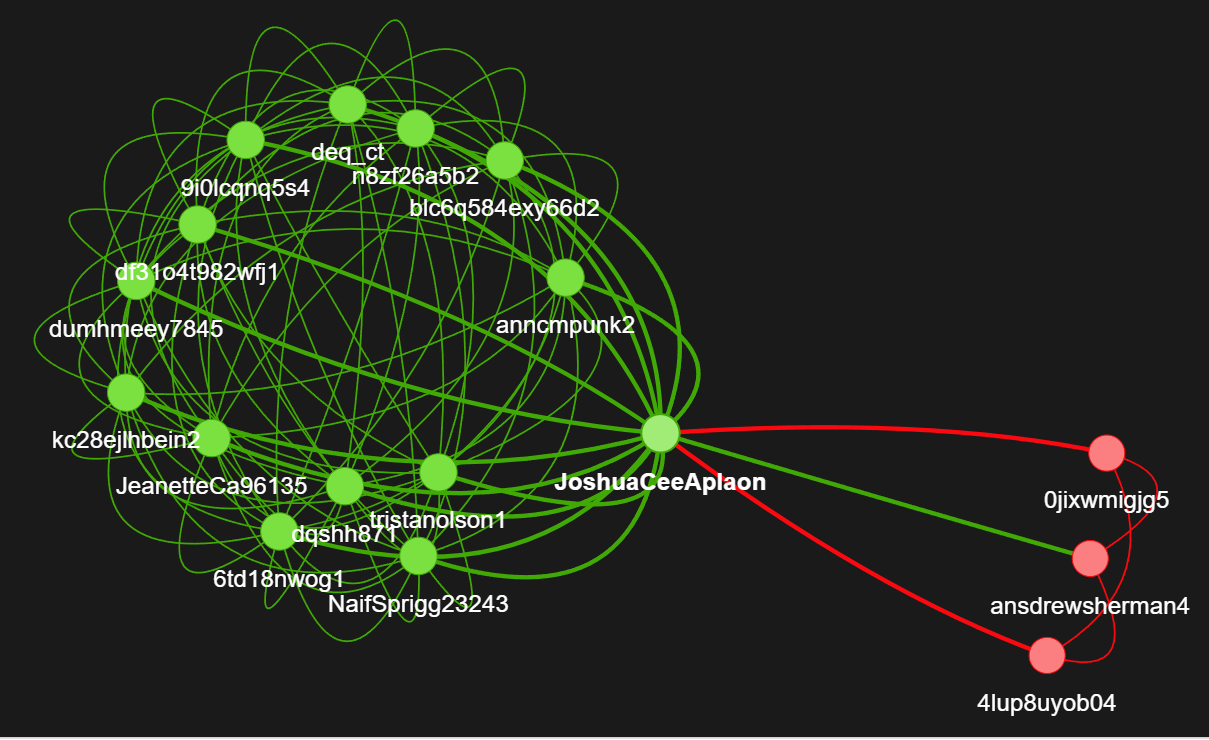

Dimana kedua kluster tersebut sebenarnya memiliki makna yang sama.

Hijau:  Februari 2024, gue udah count down buat Pesta demokrasi indonesia, guys! Yuk, sama-sama kita hitung mundur buat memilih Ganjar Pranowo. #GanjarMahfudRebound #GanjarPranowoPilihanUmat #JNK

Merah:  Februari 2024, gue udah count down buat Indonesian presidential election, guys! Yuk, sama-sama kita hitung mundur buat memilih Ganjar Pranowo. #GanjarMahfudRebound #GanjarPranowoPilihanUmat #JNK